In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error

import time
import xgboost as xgb

In [2]:
# 1. Chargement et Tri
df = pd.read_parquet('data/processed_windspeed.parquet')
df['horodatage_référence'] = pd.to_datetime(df['horodatage_référence'], dayfirst=True)
df = df.sort_values('horodatage_référence').reset_index(drop=True)

# 2. Gestion des NaN (Interpolation linéaire : relie les points logiquement en comblant les trous)
# On ne traite que les colonnes numériques
cols_num = df.select_dtypes(include=[np.number]).columns
df[cols_num] = df[cols_num].interpolate(method='linear').fillna(method='bfill')

# 3. Feature Engineering (Heure, Mois et Retards temporels)
df['hour'] = df['horodatage_référence'].dt.hour
df['month'] = df['horodatage_référence'].dt.month

# On crée des lags : le vent à T-10min et T-20min
# ? Les lags permettent d'éviter pour les premières lignes des erreurs car le programme ne trouve pas de données avant dans le temps
target = 'vitesse_vent_moyenne_10min_kmh'
df['vent_10min_avant'] = df[target].shift(1) # ? décalage des données de la colonne vers 1 en bas
df['vent_20min_avant'] = df[target].shift(2) # ? décalage des données de la colonne vers 2 en bas
df['vent_30min_avant'] = df[target].shift(3) # ? décalage des données de la colonne vers 3 en bas
df['vent_40min_avant'] = df[target].shift(4) # ? décalage des données de la colonne vers 4 en bas
df['vent_50min_avant'] = df[target].shift(5) # ? décalage des données de la colonne vers 5 en bas
df['vent_60min_avant'] = df[target].shift(6) # ? décalage des données de la colonne vers 6 en bas

df['vent_tendance_1h'] = df[target] - df['vent_60min_avant']

df['pression_atmospherique_6h'] = df['pression_barométrique_qfe'].shift(36) # ? décalage des données de la colonne vers 36 en bas
df['pression_tendance_6h'] = df['pression_barométrique_qfe'] - df['pression_atmospherique_6h']

# On supprime les lignes du début devenues NaN à cause du décalage (shift)
df = df.dropna(subset=['vent_10min_avant', 
                       'vent_20min_avant', 
                       'vent_30min_avant', 
                       'vent_40min_avant', 
                       'vent_50min_avant', 
                       'vent_60min_avant',
                       'pression_tendance_6h'])

### Choix des variables + Split

In [4]:
# Choix des variables explicatives (Features)
# On évite de mettre les autres colonnes de vent "moyenne" qui donneraient la réponse au modèle
features = [
    'vent_10min_avant', 
    'vent_20min_avant',
    'vent_30min_avant', 
    'vent_40min_avant', 
    'vent_50min_avant', 
    'vent_60min_avant',
    'vent_tendance_1h',
    'direction_du_vent_moyenne_10min',
    'hour', 
    'month',
    'pression_tendance_6h',
    'humidité',
    'température_air',
    'rafale_3s_maximum_kmh'
]

# On s'assure que les colonnes existent avant de split
features = [f for f in features if f in df.columns]

# Split chronologique (le passé sert d'entrainement)
split_idx = int(len(df) * 0.8) # longueur du df - 80% sont gardés pour le train et 20% pour le test
train_df = df.iloc[:split_idx] # on prend tout ce qui avant l'index
test_df = df.iloc[split_idx:] # on prend tout ce qui a après l'index

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# On prépare les données dans le format "DMatrix" (optimisé GPU)
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

### Création du pipeline + entrainement + prédiction + résultats

🚀 Lancement de l'entraînement GPU sur 909288 lignes...
✅ Terminé en 4.15 secondes (soit 0.07 minutes)
--- RÉSULTATS ---
Score R² (TEST) : 0.9971
Score R² (TRAIN) : 0.9986 (Pour vérifier l'overfitting)
Erreur moyenne (MAE) : 0.14 km/h
RMSE : 0.37 km/h


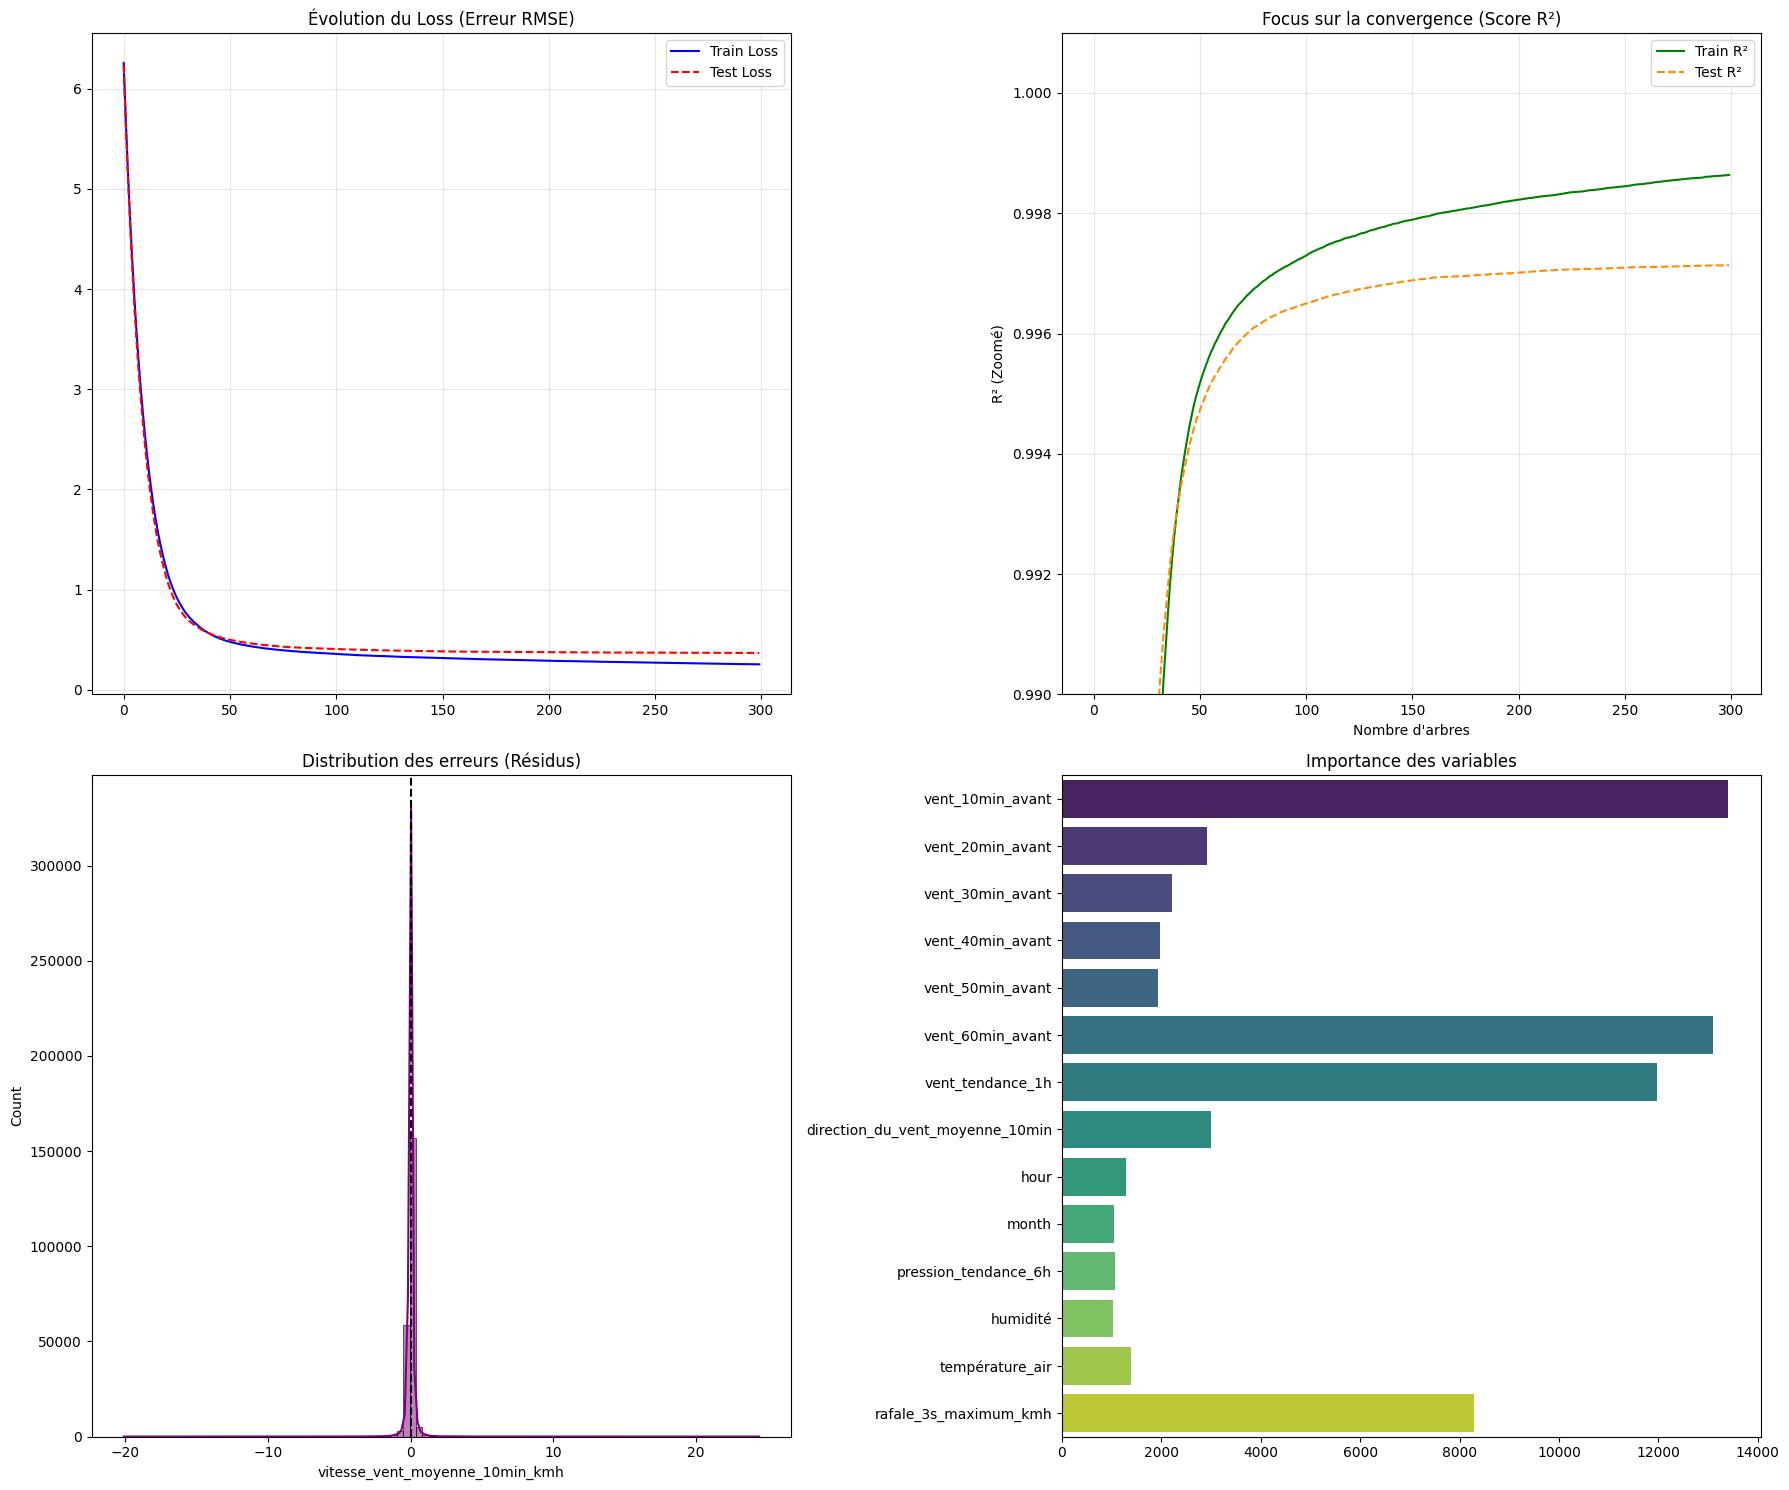

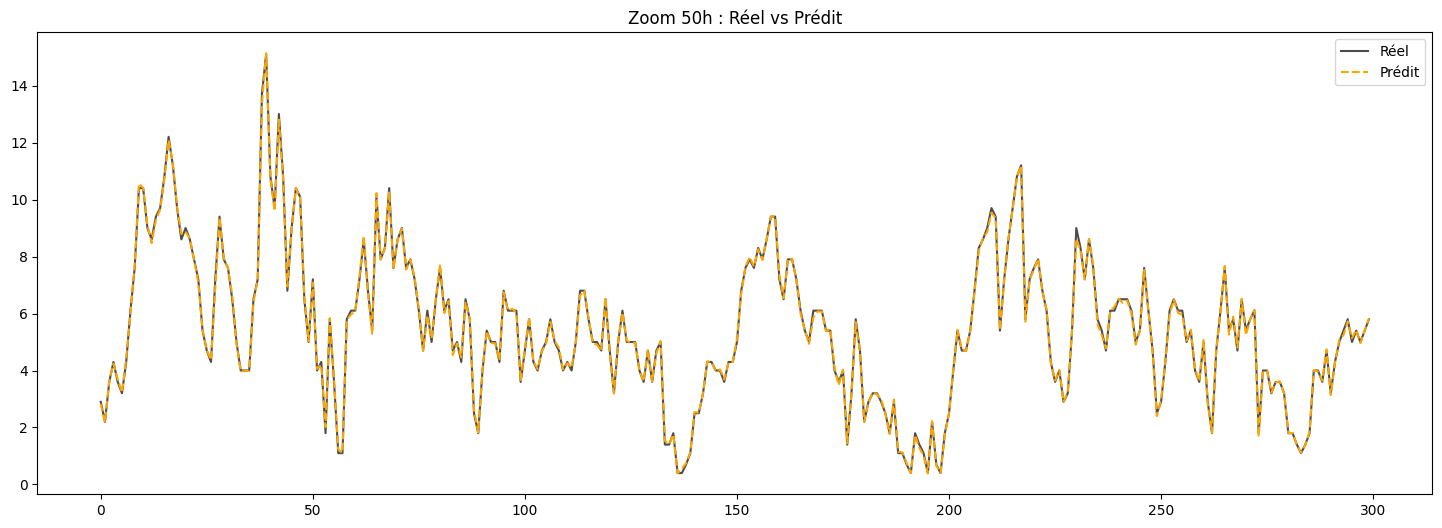

In [6]:
# 1. Configuration du modèle pour GPU
params = {
    'max_depth': 8,
    'eta': 0.1, # = learning rate (si trop élevé = risque d'overfitting) -> défaut = 0.3
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': 42
}

evals_result = {} # Création du dictionnaire pour les graphiques

print(f"🚀 Lancement de l'entraînement GPU sur {len(X_train)} lignes...")
start_time = time.time() # on déclenche le chrono

model = xgb.train(params, 
                  dtrain, 
                  num_boost_round=300, # nombre d'arbres
                  evals=[(dtrain, 'train'), (dtest, 'test')], 
                  evals_result=evals_result,                  
                  verbose_eval=False
)

end_time = time.time()
duree = end_time - start_time # calcul du temps

print(f"✅ Terminé en {duree:.2f} secondes (soit {duree/60:.2f} minutes)")

# Prédiction
y_pred = model.predict(dtest)
y_pred_train = model.predict(dtrain)

# ÉVALUATION AVANCÉE
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_pred_train)

mask = y_test > 0.5
mape_clean = mean_absolute_percentage_error(y_test[mask], y_pred[mask])

print(f"--- RÉSULTATS ---")
print(f"Score R² (TEST) : {r2:.4f}")
print(f"Score R² (TRAIN) : {r2_train:.4f} (Pour vérifier l'overfitting)")
print(f"Erreur moyenne (MAE) : {mae:.2f} km/h")
print(f"RMSE : {rmse:.2f} km/h")


#####################################################################################################################
# --- NOUVEAU : CALCUL DE L'ACCURACY (R²) PAR ÉTAPE ---
# On transforme le MSE stocké par XGBoost en score R2 approximatif pour le graph
train_mse = np.array(evals_result['train']['rmse'])**2
test_mse = np.array(evals_result['test']['rmse'])**2
var_y = np.var(y_test)
train_r2_history = 1 - (train_mse / np.var(y_train))
test_r2_history = 1 - (test_mse / var_y)

# Visualisations / Graphiques
plt.figure(figsize=(18, 15))

# --- GRAPHIQUE 1 : TRAIN & TEST LOSS (RMSE) ---
plt.subplot(2, 2, 1)
metric_name = 'rmse'
epochs = len(evals_result['train'][metric_name])
plt.plot(range(epochs), evals_result['train'][metric_name], label='Train Loss', color='blue')
plt.plot(range(epochs), evals_result['test'][metric_name], label='Test Loss', color='red', linestyle='--')
plt.title("Évolution du Loss (Erreur RMSE)")
plt.legend()
plt.grid(alpha=0.3)

# --- GRAPHIQUE 2 : TRAIN & TEST "ACCURACY" (R²) ZOOMÉ ---
plt.subplot(2, 2, 2)
plt.plot(range(epochs), train_r2_history, label='Train R²', color='green')
plt.plot(range(epochs), test_r2_history, label='Test R²', color='darkorange', linestyle='--')

# On cherche la valeur minimale de R2 après le 50ème arbre pour caler le bas du graphique
# Si le modèle est déjà très haut, on peut aussi forcer une valeur fixe comme 0.90 ou 0.95
valeur_min_zoom = max(0.99, np.min(test_r2_history[10:])) 
plt.ylim(valeur_min_zoom, 1.001) # On s'arrête juste au dessus de 1

plt.title("Focus sur la convergence (Score R²)")
plt.xlabel("Nombre d'arbres")
plt.ylabel("R² (Zoomé)")
plt.legend()
plt.grid(alpha=0.3, which='both') # 'both' pour voir les petites lignes de grille

# --- GRAPHIQUE 3 : DISTRIBUTION DES ERREURS ---
plt.subplot(2, 2, 3)
residus = y_test - y_pred
sns.histplot(residus, bins=100, kde=True, color='purple')
plt.axvline(x=0, color='black', linestyle='--')
plt.title("Distribution des erreurs (Résidus)")

# --- GRAPHIQUE 4 : IMPORTANCE DES VARIABLES ---
plt.subplot(2, 2, 4)
importance_dict = model.get_score(importance_type='weight')
importances = [importance_dict.get(f, 0) for f in features]
sns.barplot(x=importances, y=features, palette='viridis')
plt.title("Importance des variables")

plt.tight_layout()
plt.show()

# --- GRAPHIQUE FINAL : ZOOM TEMPOREL ---
plt.figure(figsize=(18, 6))
plt.plot(y_test.values[:300], label='Réel', color='black', alpha=0.7)
plt.plot(y_pred[:300], label='Prédit', color='orange', linestyle='--')
plt.title("Zoom 50h : Réel vs Prédit")
plt.legend()
plt.show()

In [12]:
model.save_model('models/model_vent_10min.json')